In [53]:
# .importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [54]:
# Load the data
df = pd.read_csv("data/nepse_stock_prices.csv") 



In [55]:
df.columns = df.columns.str.strip()

In [56]:

df["published_date"] = pd.to_datetime(df["published_date"])
df = df.sort_values("published_date")

df.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,Symbol
28246,2003-06-06,143.0,145.0,145.0,145.0,NaN,90.0,0.0,0,CFCL
28247,2003-06-09,145.0,145.0,145.0,145.0,0.00,200.0,0.0,0,CFCL
28248,2003-06-13,145.0,149.0,149.0,149.0,2.76,30.0,0.0,0,CFCL
28249,2003-06-18,149.0,150.0,150.0,150.0,0.67,40.0,0.0,0,CFCL
28250,2003-06-19,150.0,151.0,150.0,151.0,0.67,760.0,0.0,0,CFCL


In [57]:
# clean the data
print(df.isnull().sum())

df = df.drop_duplicates()
df = df.reset_index(drop=True)

published_date      0
open                0
high                0
low                 0
close               0
per_change         87
traded_quantity     0
traded_amount       0
status              0
Symbol              0
dtype: int64


In [58]:
# RSI Function
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

In [72]:
# feature 


# Keep only numeric columns
df = df.select_dtypes(include=[np.number]).copy()

# Check columns (IMPORTANT)
print("Columns after filtering:", df.columns)

# Separate target
X = df.drop("target", axis=1)
y = df["target"]

# Split
split = int(len(X) * 0.8)

X_train = X.iloc[:split].copy()
X_test = X.iloc[split:].copy()

y_train = y.iloc[:split].copy()
y_test = y.iloc[split:].copy()

print("✅ Feature selection done")

Columns after filtering: Index(['open', 'high', 'low', 'close', 'per_change', 'traded_quantity',
       'traded_amount', 'status', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5',
       'ma5', 'ma10', 'ma20', 'std5', 'return_1d', 'return_5d', 'rsi',
       'target'],
      dtype='object')
✅ Feature selection done


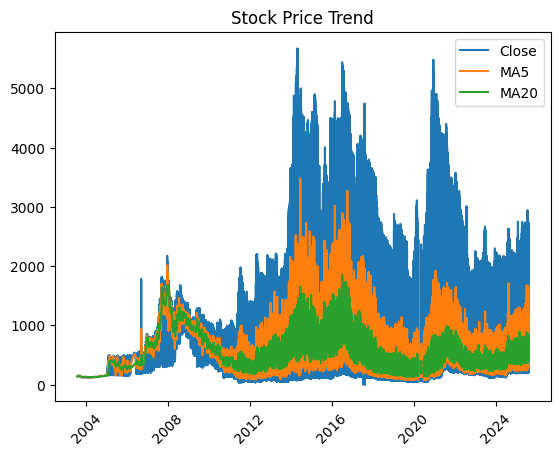

In [66]:
# visual
plt.figure()
plt.plot(df["published_date"], df["close"], label="Close")
plt.plot(df["published_date"], df["ma5"], label="MA5")
plt.plot(df["published_date"], df["ma20"], label="MA20")

plt.title("Stock Price Trend")
plt.legend()
plt.xticks(rotation=45)
plt.show()

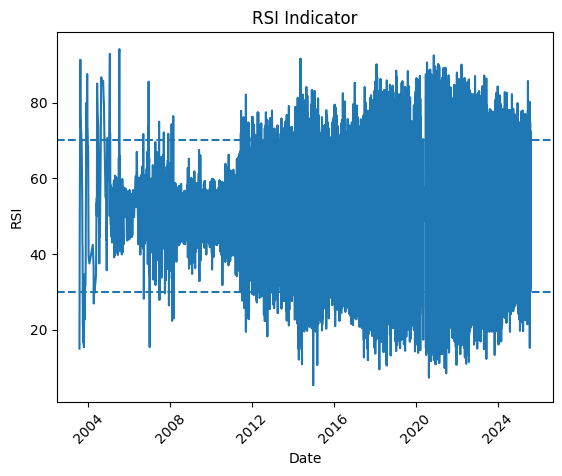

In [67]:
# RSI Chart
plt.figure()
plt.plot(df["published_date"], df["rsi"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.xticks(rotation=45)
plt.show()

In [69]:
# prepare the data
features = [col for col in df.columns if col not in ["published_date", "target", "close"]]

X = df[features]
y = df["target"]

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [73]:
# Scaling

scaler = StandardScaler()

# Fit on train, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Scaling successful")

✅ Scaling successful


In [74]:
# model training
# Models
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# Train
xgb.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [75]:
# Ensemble Prediction
# Individual predictions (log scale)
p_xgb = xgb.predict(X_test_scaled)
p_rf = rf.predict(X_test)
p_gb = gb.predict(X_test)

# Convert back to price
p_xgb = np.exp(p_xgb)
p_rf = np.exp(p_rf)
p_gb = np.exp(p_gb)

y_actual = np.exp(y_test)

# 🔥 Final Ensemble
final_pred = 0.5*p_xgb + 0.3*p_rf + 0.2*p_gb

In [76]:
# Accuracy Metrics
mae = mean_absolute_error(y_actual, final_pred)
rmse = np.sqrt(mean_squared_error(y_actual, final_pred))
r2 = r2_score(y_actual, final_pred)
mape = np.mean(np.abs((y_actual - final_pred) / y_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAPE (%):", mape)
print("Accuracy (%):", 100 - mape)

MAE: 200.30516072598473
RMSE: 341.0343721076132
R2 Score: -0.019984880376091585
MAPE (%): 43.09294657396434
Accuracy (%): 56.90705342603566


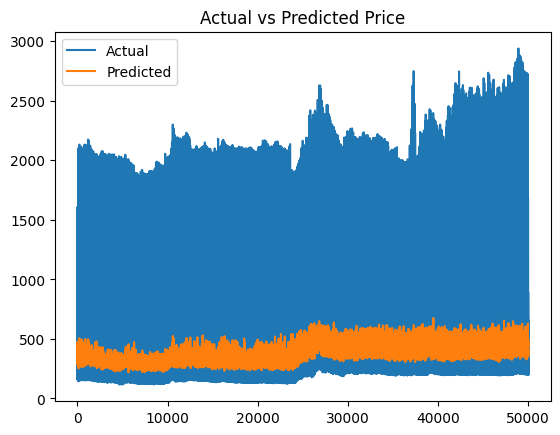

In [77]:
# Acutal vs predicted
plt.figure()
plt.plot(y_actual.values, label="Actual")
plt.plot(final_pred, label="Predicted")

plt.title("Actual vs Predicted Price")
plt.legend()
plt.show()

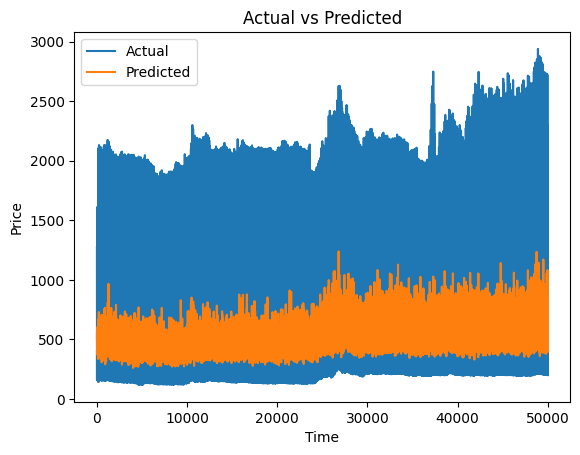

In [50]:
plt.figure()
plt.plot(range(len(y_test)), y_test.values, label="Actual")
plt.plot(range(len(final_pred)), final_pred, label="Predicted")

plt.title("Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [78]:
# next prediction
last_row = X.iloc[-1:]

xgb_p = xgb.predict(scaler.transform(last_row))
rf_p = rf.predict(last_row)
gb_p = gb.predict(last_row)

pred = 0.5*np.exp(xgb_p) + 0.3*np.exp(rf_p) + 0.2*np.exp(gb_p)

print("Next Day Predicted Price:", pred[0])

Next Day Predicted Price: 399.1851139306266


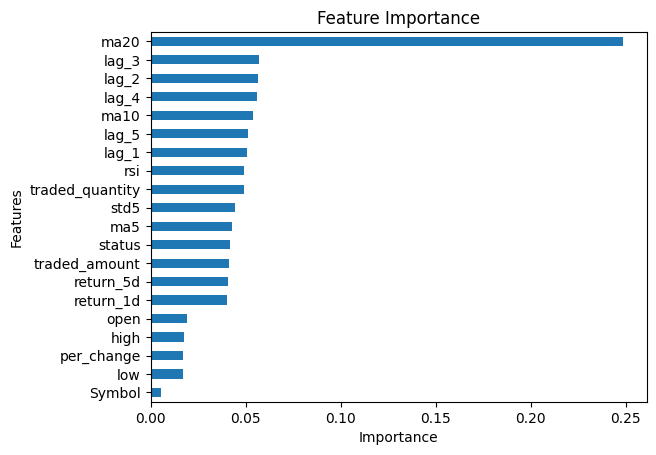

In [79]:
importance = rf.feature_importances_

feat_imp = pd.Series(importance, index=features)

plt.figure()
feat_imp.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()